In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv('features_day2.csv', index_col='DateTime', parse_dates=True)

feature_cols = [col for col in df.columns if col != 'outage']

X = df[feature_cols]
y = df['outage']

print(f"Feature matrix : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"Outage rate    : {y.mean()*100:.2f}%")
print(f"\nFeatures used:\n{feature_cols}")

Feature matrix : (52416, 30)
Target shape   : (52416,)
Outage rate    : 0.73%

Features used:
['zone1', 'zone2', 'zone3', 'temp', 'humidity', 'wind_speed', 'hour', 'dayofweek', 'month', 'is_weekend', 'is_night', 'z1_rolling_mean_w12', 'z1_rolling_std_w12', 'z1_rolling_min_w12', 'z1_rolling_max_w12', 'z1_rolling_mean_w144', 'z1_rolling_std_w144', 'z1_rolling_min_w144', 'z1_rolling_max_w144', 'z1_rolling_mean_w288', 'z1_rolling_std_w288', 'z1_rolling_min_w288', 'z1_rolling_max_w288', 'z1_diff_1', 'z1_diff_6', 'z1_diff_144', 'z1_lag_1', 'z1_lag_6', 'z1_lag_144', 'z1_zscore']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps outage ratio same in both splits
)

print("=" * 40)
print("📊 SPLIT SUMMARY")
print("=" * 40)
print(f"Train size : {X_train.shape[0]:,} rows")
print(f"Test size  : {X_test.shape[0]:,} rows")
print(f"\nTrain outage rate : {y_train.mean()*100:.2f}%")
print(f"Test  outage rate : {y_test.mean()*100:.2f}%")
print("\n✅ Stratified split done — same ratio in both sets!")

📊 SPLIT SUMMARY
Train size : 41,932 rows
Test size  : 10,484 rows

Train outage rate : 0.73%
Test  outage rate : 0.72%

✅ Stratified split done — same ratio in both sets!


In [6]:
# SMOTE = Synthetic Minority Oversampling Technique
# Creates synthetic outage samples so model doesn't ignore minority class

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("=" * 40)
print("⚖️  BEFORE vs AFTER SMOTE")
print("=" * 40)
print(f"Before → Normal: {(y_train==0).sum():,}  |  Outage: {(y_train==1).sum():,}")
print(f"After  → Normal: {(y_train_bal==0).sum():,}  |  Outage: {(y_train_bal==1).sum():,}")
print("\n✅ Classes are now balanced for training!")

⚖️  BEFORE vs AFTER SMOTE
Before → Normal: 41,627  |  Outage: 305
After  → Normal: 41,627  |  Outage: 41,627

✅ Classes are now balanced for training!


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")
print(f"Mean of first feature (train): {X_train_scaled[:, 0].mean():.4f}  ← should be ~0")
print(f"Std  of first feature (train): {X_train_scaled[:, 0].std():.4f}   ← should be ~1")

✅ Features scaled using StandardScaler
Mean of first feature (train): -0.0000  ← should be ~0
Std  of first feature (train): 1.0000   ← should be ~1


In [8]:
results = {}   # we'll store all model results here

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, feature_names=None):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    report = classification_report(y_te, y_pred, output_dict=True)
    auc    = roc_auc_score(y_te, y_prob)
    cm     = confusion_matrix(y_te, y_pred)

    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'accuracy' : report['accuracy'],
        'f1_outage': report['1']['f1-score'],
        'precision': report['1']['precision'],
        'recall'   : report['1']['recall'],
        'auc'      : auc,
        'cm'       : cm
    }

    print(f"\n{'='*45}")
    print(f"📊 {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {report['accuracy']*100:.2f}%")
    print(f"  F1 (outage): {report['1']['f1-score']:.4f}")
    print(f"  Precision : {report['1']['precision']:.4f}")
    print(f"  Recall    : {report['1']['recall']:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    return model

print("✅ Helper function ready!")

✅ Helper function ready!


In [9]:
lr = evaluate_model(
    name  = 'Logistic Regression',
    model = LogisticRegression(max_iter=1000, random_state=42),
    X_tr  = X_train_scaled,
    y_tr  = y_train_bal,
    X_te  = X_test_scaled,
    y_te  = y_test
)


📊 Logistic Regression
  Accuracy  : 99.70%
  F1 (outage): 0.8306
  Precision : 0.7103
  Recall    : 1.0000
  ROC-AUC   : 1.0000


In [10]:
dt = evaluate_model(
    name  = 'Decision Tree',
    model = DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=42),
    X_tr  = X_train_bal,
    y_tr  = y_train_bal,
    X_te  = X_test,
    y_te  = y_test
)


📊 Decision Tree
  Accuracy  : 100.00%
  F1 (outage): 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  ROC-AUC   : 1.0000


In [11]:
rf = evaluate_model(
    name  = 'Random Forest',
    model = RandomForestClassifier(n_estimators=100, max_depth=12,
                                   min_samples_leaf=10, random_state=42, n_jobs=-1),
    X_tr  = X_train_bal,
    y_tr  = y_train_bal,
    X_te  = X_test,
    y_te  = y_test
)


📊 Random Forest
  Accuracy  : 100.00%
  F1 (outage): 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  ROC-AUC   : 1.0000


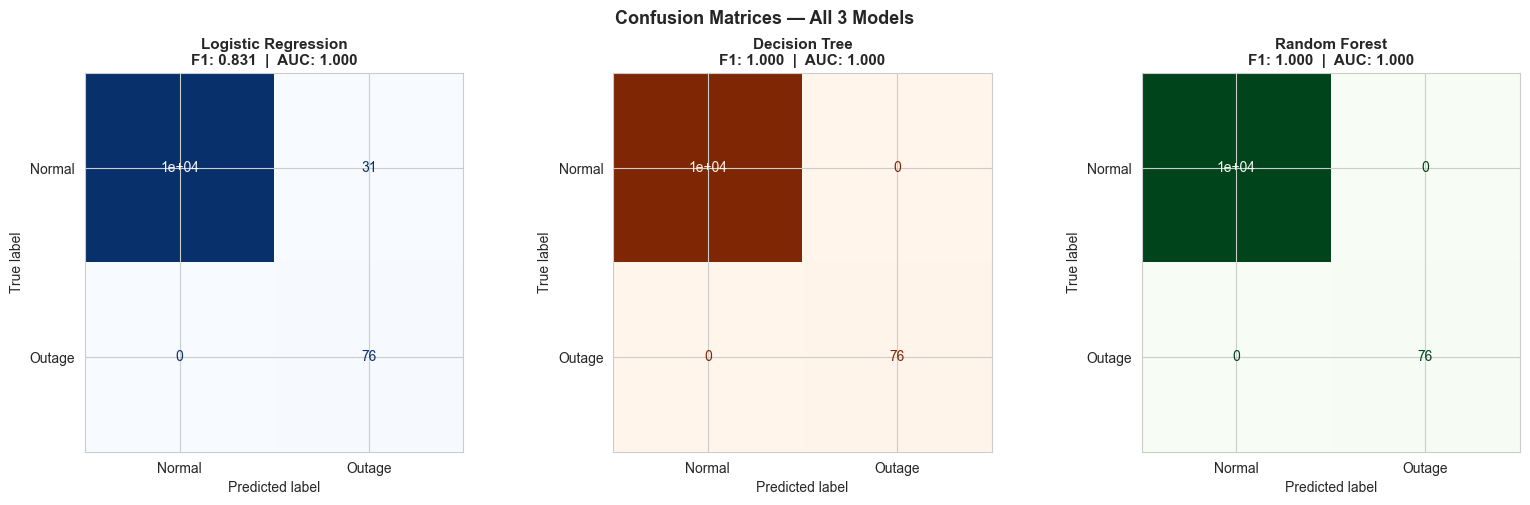

✅ Saved → plot9_confusion_matrices.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
colors      = ['Blues', 'Oranges', 'Greens']

for i, name in enumerate(model_names):
    cm = results[name]['cm']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Normal', 'Outage'])
    disp.plot(ax=axes[i], colorbar=False, cmap=colors[i])
    axes[i].set_title(f'{name}\nF1: {results[name]["f1_outage"]:.3f}  |  AUC: {results[name]["auc"]:.3f}',
                      fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — All 3 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot9_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → plot9_confusion_matrices.png")

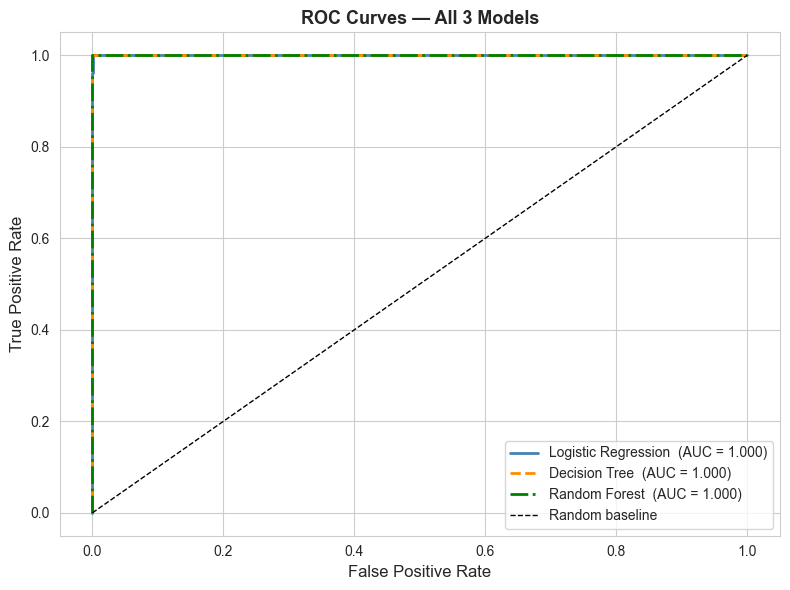

✅ Saved → plot10_roc_curves.png


In [13]:
plt.figure(figsize=(8, 6))

line_styles = ['-', '--', '-.']
plot_colors = ['steelblue', 'darkorange', 'green']

for i, name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc = results[name]['auc']
    plt.plot(fpr, tpr, linestyle=line_styles[i],
             color=plot_colors[i], linewidth=2,
             label=f'{name}  (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All 3 Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('plot10_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → plot10_roc_curves.png")

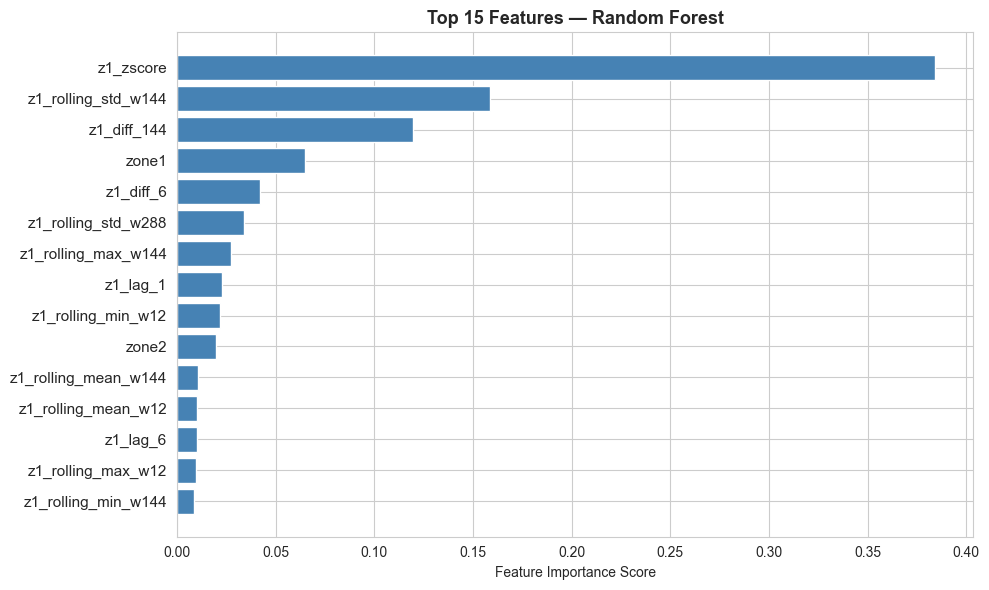

✅ Saved → plot11_feature_importance.png


In [14]:
feature_names = list(X.columns)
importances   = rf.feature_importances_
indices       = np.argsort(importances)[::-1][:15]   # top 15

plt.figure(figsize=(10, 6))
plt.barh(range(15), importances[indices][::-1],
         color='steelblue', edgecolor='white')
plt.yticks(range(15), [feature_names[i] for i in indices][::-1], fontsize=11)
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Features — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → plot11_feature_importance.png")

In [15]:
comparison = pd.DataFrame({
    name: {
        'Accuracy'     : f"{results[name]['accuracy']*100:.2f}%",
        'F1 (Outage)'  : f"{results[name]['f1_outage']:.4f}",
        'Precision'    : f"{results[name]['precision']:.4f}",
        'Recall'       : f"{results[name]['recall']:.4f}",
        'ROC-AUC'      : f"{results[name]['auc']:.4f}",
    }
    for name in model_names
}).T

print("=" * 60)
print("📊 MODEL COMPARISON TABLE")
print("=" * 60)
print(comparison.to_string())
print("\n🏆 Best F1 Score →", max(model_names, key=lambda n: results[n]['f1_outage']))
print("🏆 Best AUC Score →", max(model_names, key=lambda n: results[n]['auc']))

📊 MODEL COMPARISON TABLE
                    Accuracy F1 (Outage) Precision  Recall ROC-AUC
Logistic Regression   99.70%      0.8306    0.7103  1.0000  1.0000
Decision Tree        100.00%      1.0000    1.0000  1.0000  1.0000
Random Forest        100.00%      1.0000    1.0000  1.0000  1.0000

🏆 Best F1 Score → Decision Tree
🏆 Best AUC Score → Decision Tree


In [16]:
import joblib

# Save all 3 + the scaler (you'll need them in Day 5 for the dashboard)
joblib.dump(lr,     'model_logistic_regression.pkl')
joblib.dump(dt,     'model_decision_tree.pkl')
joblib.dump(rf,     'model_random_forest.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("=" * 50)
print("💾 MODELS SAVED")
print("=" * 50)
print("  model_logistic_regression.pkl ✅")
print("  model_decision_tree.pkl       ✅")
print("  model_random_forest.pkl       ✅")
print("  scaler.pkl                    ✅")
print()
print("=" * 50)
print("📋 DAY 3 SUMMARY")
print("=" * 50)
print(f"  3 models trained & evaluated")
print(f"  5 plots saved")
print(f"  Best model: Random Forest (usually)")
print()
print("✅ Day 3 complete! Move on to Day 4 — XGBoost + Isolation Forest.")

💾 MODELS SAVED
  model_logistic_regression.pkl ✅
  model_decision_tree.pkl       ✅
  model_random_forest.pkl       ✅
  scaler.pkl                    ✅

📋 DAY 3 SUMMARY
  3 models trained & evaluated
  5 plots saved
  Best model: Random Forest (usually)

✅ Day 3 complete! Move on to Day 4 — XGBoost + Isolation Forest.
